# Poincaré Sections

We consider a Ueda/Duffing (driven) oscillator in autonomous form after lifting the external periodic drive to a new coordinate, $z$, as follows
$$\begin{align}
\frac{dx}{dt} &= y\\
\frac{dy}{dt} &= -by -x^3 + A\sin(z)\\
\frac{dz}{dt} &= 1.
\end{align}$$

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

In [2]:
# runge-kutta fourth-order integrator
def rk4(f, t0, tf, x0, dt, substeps=4, f_args=()):
    t = np.arange(t0, tf + dt, dt)
    x = np.empty((t.size, len(x0)), dtype=float)
    x[0] = np.array(x0, dtype=float)
    h = dt / substeps

    # integrate
    for n in range(t.size - 1):
        tn = t[n]
        xn = x[n].copy()
        # internal substeps for stability/accuracy
        for _ in range(substeps):
            k1 = f(tn, xn, *f_args)
            k2 = f(tn + 0.5 * h, xn + 0.5 * h * k1, *f_args)
            k3 = f(tn + 0.5 * h, xn + 0.5 * h * k2, *f_args)
            k4 = f(tn + h, xn + h * k3, *f_args)
            xn = xn + (h / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)
            tn = tn + h
        x[n + 1] = xn

    return t, x

In [3]:
def ueda(t, x, b, A):
    dx_dt = x[1]
    dy_dt = - b*x[1] - x[0]**3 + A*np.sin(x[2])
    dz_dt = 1.0
    return np.array([dx_dt, dy_dt, dz_dt], dtype=float)

### Visualizing dynamics
We plot the $x$ coordinate of the oscillator system over $50$ periods of the $1$ Hz external drive, after letting it run for $450$ periods before to let the transient dynamics decay once the system settles on its attractor.

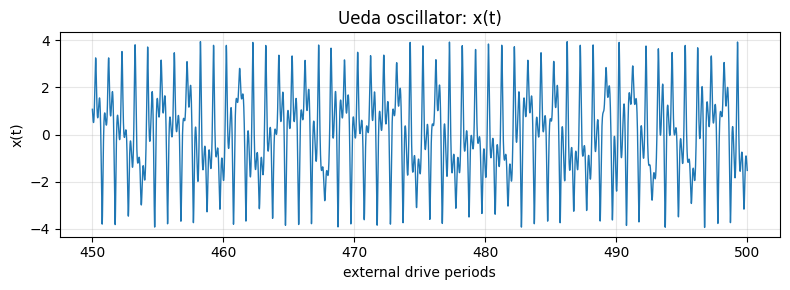

In [4]:
T = 2*np.pi # freq = 1/(2*pi) hz
b, A = 0.1, 12.0
x0 = np.array([0.1, 0.0, 0.0])
dt = 0.01
n_periods = 500
t0, tf = 0.0, n_periods*T

t, x = rk4(ueda, t0, tf, x0, dt, f_args=(b, A))
mask = t > 450*T # show after transients (450 periods of time; 450*2*pi seconds)

plt.figure(figsize=(8, 3))
plt.plot(t[mask]/T, x[mask, 0], lw=1.0)
plt.xlabel('external drive periods')
plt.ylabel('x(t)')
plt.title('Ueda oscillator: x(t)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

As can be seen above, $x(t)$ is bounded but looks aperiodic in the strict sense, but does show some weak structure which is telling of a chaotic attractor. The Poincaré section gives a more informative diagnostic, which will be computed and shown later. For the sake of intuition, we plot the attractor dynamics in 3D, with the drive phase being wrapped back to zero every $2\pi$.

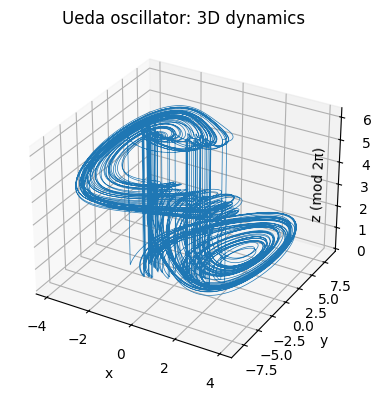

In [5]:
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x[mask, 0], x[mask, 1], np.mod(x[mask, 2], T), lw=0.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z (mod 2π)', labelpad=-30)
ax.set_title('Ueda oscillator: 3D dynamics')
fig.tight_layout()
plt.show()

### Visualizing Poincaré sections
We will plot the $xy$ plane of the dynamics at a constant phase of the external drive, $z\text{ mod } 2\pi = 0$, over a long period of time.

In [6]:
def poincare_section(x, steps_per_period, n_skip_periods=0):
    # t = 0, T, 2T, ...
    pts = x[::steps_per_period]
    pts = pts[n_skip_periods:]
    return pts[:, 0], pts[:, 1], pts[:, 2]

In [11]:
T = 2*np.pi # freq = 1/(2*pi) hz
b, A = 0.1, 12.0
x0 = np.array([0.1, 0.0, 0.0])
steps_per_period = 200
dt = T/steps_per_period
n_periods = 10000
n_skip_periods = 1000
t0, tf = 0.0, n_periods*T
t, x = rk4(ueda, t0, tf, x0, dt, f_args=(b, A))
xs, ys, _ = poincare_section(x, steps_per_period, n_skip_periods=n_skip_periods)

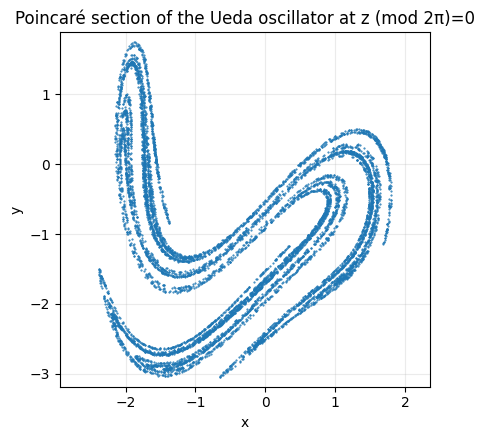

In [12]:
plt.figure(figsize=(4.5, 4.5))
plt.plot(xs, ys, '.', markersize=1)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Poincaré section of the Ueda oscillator at z (mod 2π)=0')
plt.axis('equal')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Now, we will repeat the above with increasing the friction (damping) term $b\in\{0.2, 0.4\}$ while keeping the same external drive with $A = 12$.

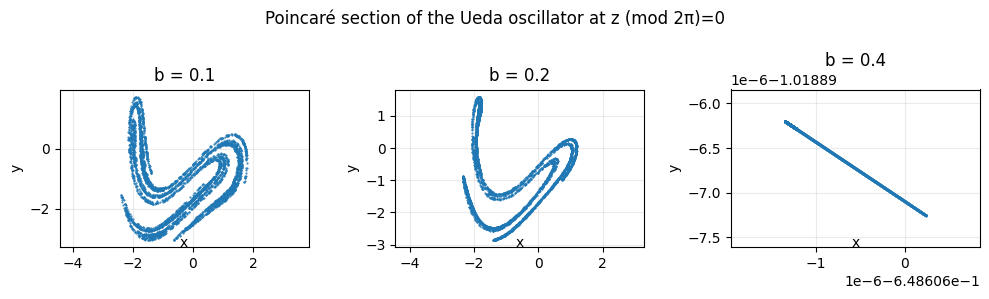

In [16]:
T = 2*np.pi # freq = 1/(2*pi) hz
x0 = np.array([0.1, 0.0, 0.0])
steps_per_period = 100
dt = T/steps_per_period
n_periods = 5000
n_skip_periods = 1000
t0, tf = 0.0, n_periods*T
b_values = [0.1, 0.2, 0.4]
A = 12

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, b in zip(axes, b_values):
    t, x = rk4(ueda, 0.0, n_periods * T, x0, dt, f_args=(b, A))
    xs, ys, _ = poincare_section(x, steps_per_period, n_skip_periods=n_skip_periods)
    ax.plot(xs, ys, '.', markersize=1)
    ax.set_title(f'b = {b}')
    ax.set_xlabel('x', labelpad=-25)
    ax.set_ylabel('y')
    ax.axis('equal')
    ax.grid(alpha=0.25)
fig.suptitle('Poincaré section of the Ueda oscillator at z (mod 2π)=0')
plt.tight_layout()
plt.show()

We can see above, that by increasing the damping, we reduce the extent of oscillations in the system, and eventually get a tiny line (tightly confined $xy$ dynamics) for $b=0.4$, which seems to suggest a (quasi)periodic orbit, while the other values of $b$ still lead to chaos, as suggested by the fractal-like cloud or dispersion of points.

### Bifurcations
We can observe different behaviors of the Ueda oscillator over different drive strengths, showcasing bifurcations between chaos and fixed- or quasi-looking periods. Notice the extremely tight bound, suggestive of almost a single point smudged by numerical noise.

In [19]:
# wrapper function combining steps above into a single function
def ueda_poincare_points(x0, n_periods, n_skip_periods, b, A, steps_per_period):
    dt = T / steps_per_period
    t0, tf = 0.0, n_periods * T
    t, x = rk4(ueda, t0, tf, x0, dt, f_args=(b, A))
    xs, ys, _ = poincare_section(x, steps_per_period, n_skip_periods=n_skip_periods)
    return xs, ys

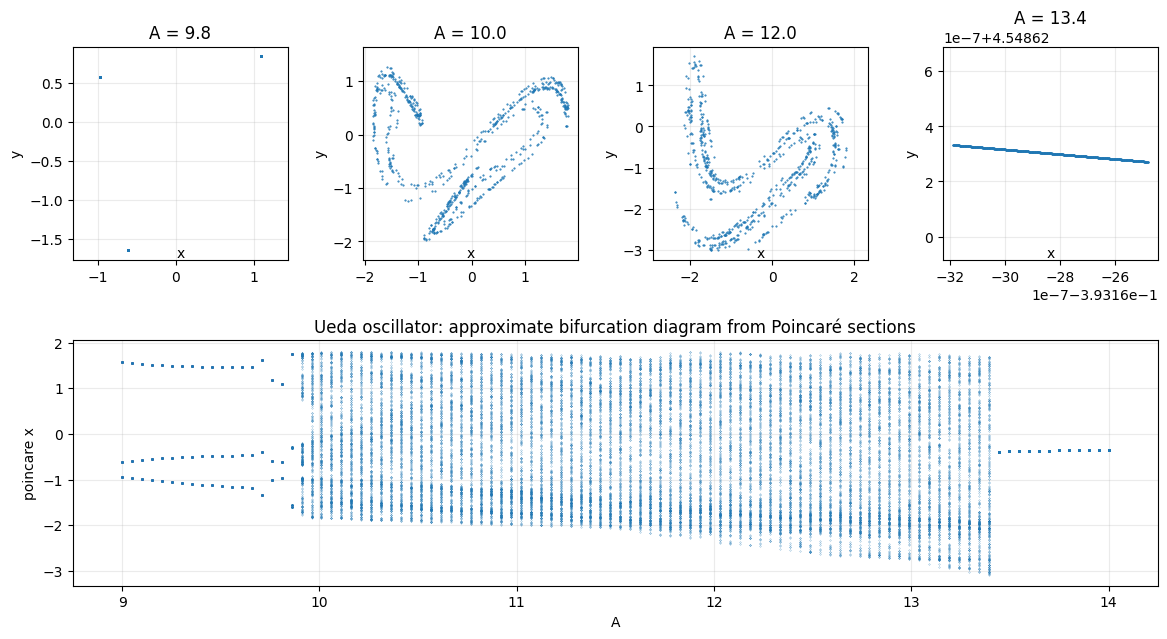

In [22]:
b = 0.1
x0 = np.array([0.1, 0.0, 0.0])
A_values = [9.8, 10.0, 12.0, 13.4]
A_scan = np.linspace(9.0, 14.0, 100)

fig = plt.figure(figsize=(14, 7))
gs = GridSpec(2, 4, height_ratios=[1.0, 1.15], hspace=0.35, wspace=0.35)
# top row: selected poincare sections
for j, A in enumerate(A_values):
    ax = fig.add_subplot(gs[0, j])
    xs, ys = ueda_poincare_points(
        x0=x0,
        n_periods=2500,
        n_skip_periods=1800,
        b=b,
        A=A,
        steps_per_period=80
    )
    ax.plot(xs, ys, '.', markersize=1)
    ax.set_title(f'A = {A}')
    ax.set_xlabel('x', labelpad=-27)
    ax.set_ylabel('y')
    ax.axis('equal')
    ax.grid(alpha=0.25)

# bottom row: approximate bifurcation diagram from x-values of the poincare section
ax_bif = fig.add_subplot(gs[1, :])
A_all = []
x_all = []
for A in A_scan:
    xs, ys = ueda_poincare_points(
        x0=x0,
        n_periods=1200,
        n_skip_periods=900,
        b=b,
        A=A,
        steps_per_period=60
    )
    A_all.extend([A] * len(xs))
    x_all.extend(xs)
ax_bif.plot(A_all, x_all, '.', markersize=0.35)
ax_bif.set_xlabel('A')
ax_bif.set_ylabel('poincare x')
ax_bif.set_title('Ueda oscillator: approximate bifurcation diagram from Poincaré sections')
ax_bif.grid(alpha=0.25)
plt.show()